In [1]:
import jax.numpy as jnp
from utils import load_run_data
import matplotlib.pyplot as plt
from notebooks.mail import email_pdf
episodic_config, episodic_metrics = load_run_data('cov_lstd_ridge/20260120_120429/', "DeepSea-bsuite", 'results')

📧 Email functions ready!
Try: test_email() first, then email_pdf_simple()


In [2]:
SEED = 3
plt.plot(episodic_metrics['v_e'][SEED, :, 0, 0])

KeyError: 'v_e'

Text(0.5, 1.0, 'Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values')

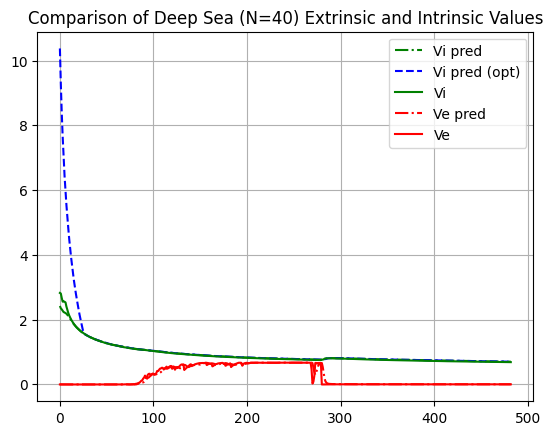

In [ ]:
N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

# plt.plot(episodic_metrics['returned_episode_returns'].mean(0), label = 'Episodic Return')
# plt.plot(continuing_metrics['returned_episode_returns'].mean(0), label = 'Continuing Ret')
plt.plot((episodic_metrics['vi_pred'][SEED] * reachable_mask[None,:])[5:, 0, 0], label = 'Vi pred', color = 'green', ls = '-.')
plt.plot((episodic_metrics['v_i_pred_opt'][SEED] * reachable_mask[None,:])[5:, 0, 0], label = 'Vi pred (opt)', color = 'blue', ls = '--')
plt.plot((episodic_metrics['v_i'][SEED] * reachable_mask[None,:])[5:, 0, 0], label = 'Vi', color = 'green', ls = '-')
plt.plot((episodic_metrics['v_e_pred'][SEED] * reachable_mask[None,:])[5:, 0, 0], label = 'Ve pred', color = 'red', ls = '-.')
plt.plot((episodic_metrics['v_e'][SEED] * reachable_mask[None,:])[5:, 0, 0], label = 'Ve', color = 'red', ls = '-')

plt.legend()
plt.grid()
plt.title('Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values')

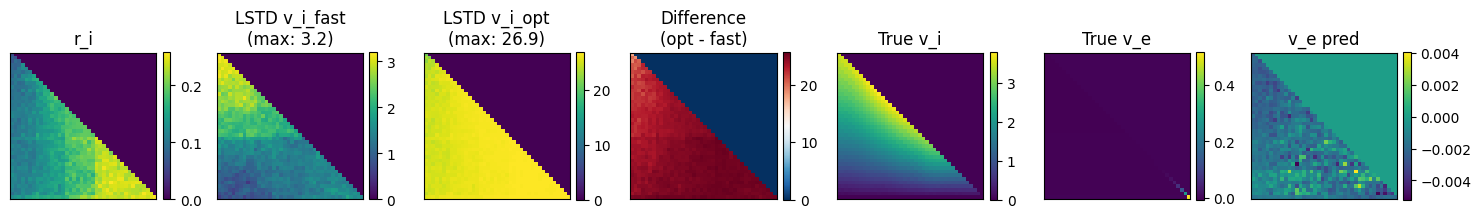

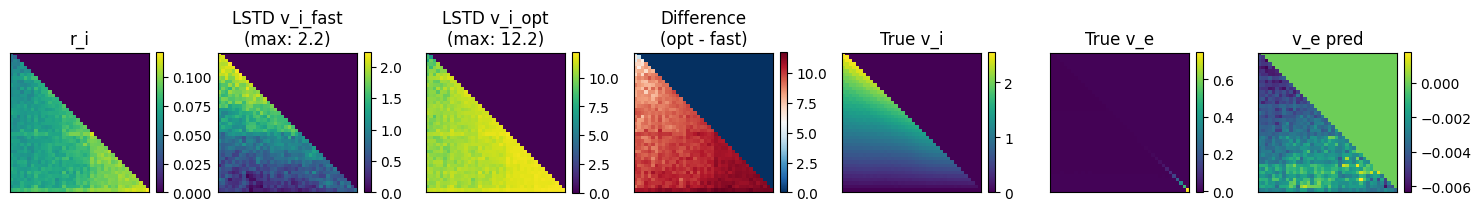

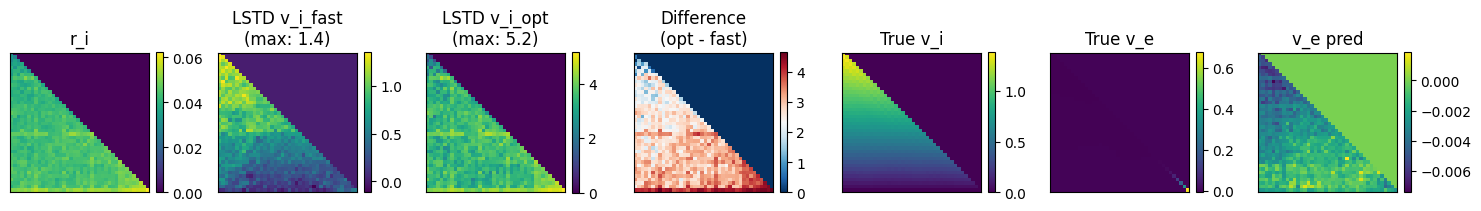

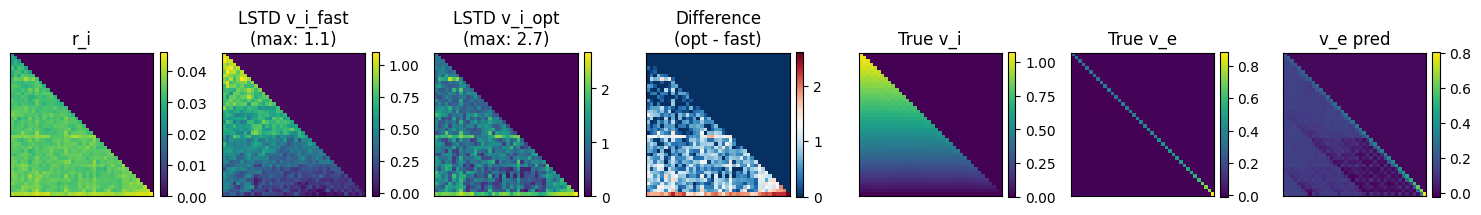

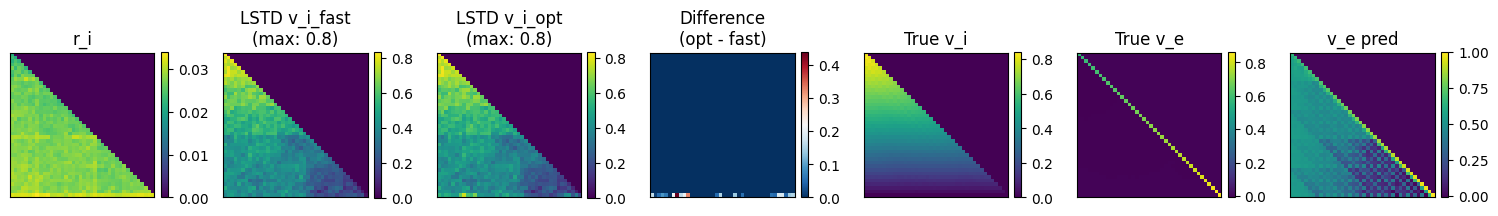

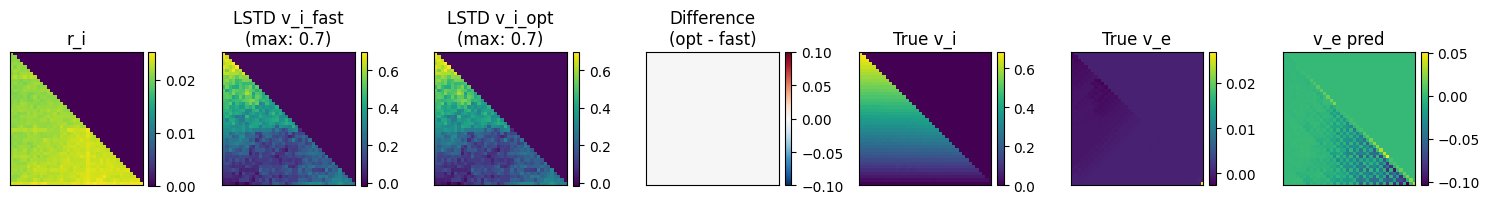

In [49]:
import matplotlib.pyplot as plt
import time

N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))
Ts = [1, 10, 50, 100, 200, 500]
for T in Ts:
    fig, axes = plt.subplots(1, 7, figsize=(15, 4))
    # --- Plot 1: r_i ---
    im0 = axes[0].imshow(episodic_metrics['ri_grid'][SEED][T] * reachable_mask, 
                         vmin=(episodic_metrics['ri_grid'][SEED][T]* reachable_mask).min())
    axes[0].set_title("r_i")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # --- Plot 2: v_i_fast (its own scale) ---
    im1 = axes[1].imshow(episodic_metrics['vi_pred'][SEED][T] * reachable_mask, 
                                                  vmin=(episodic_metrics['vi_pred'][SEED][T]* reachable_mask).min()
    )
    axes[1].set_title(f"LSTD v_i_fast\n(max: {jnp.max(episodic_metrics['vi_pred'][SEED][T] * reachable_mask):.1f})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # --- Plot 3: v_i_opt (its own scale) ---
    im2 = axes[2].imshow(episodic_metrics['v_i_pred_opt'][SEED][T] * reachable_mask,
                                                  vmin=(episodic_metrics['v_i_pred_opt'][SEED][T]* reachable_mask).min()
    )
    axes[2].set_title(f"LSTD v_i_opt\n(max: {jnp.max(episodic_metrics['v_i_pred_opt'][SEED][T] * reachable_mask):.1f})")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # --- Plot 4: Difference (opt - fast) ---
    diff = (episodic_metrics['v_i_pred_opt'][SEED][T] - episodic_metrics['vi_pred'][SEED][T]) * reachable_mask
    im3 = axes[3].imshow(diff, cmap='RdBu_r', vmin=0, vmax=jnp.max(jnp.abs(diff)))
    axes[3].set_title("Difference\n(opt - fast)")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    # # # --- Plot 5: True v_i ---
    im4 = axes[4].imshow(episodic_metrics['v_i'][SEED][T] * reachable_mask,
                            vmin=(episodic_metrics['v_i'][SEED][T]* reachable_mask).min()
    )
    axes[4].set_title("True v_i")
    plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

        # # # --- Plot 5: True v_i ---
    im5 = axes[5].imshow(episodic_metrics['v_e'][SEED][T]* reachable_mask,
                            vmin=(episodic_metrics['v_e'][SEED][T]* reachable_mask).min()
    )
    axes[5].set_title("True v_e")
    plt.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

        # # # --- Plot 5: True v_i ---
    im6 = axes[6].imshow(episodic_metrics['v_e_pred'][SEED][T]* reachable_mask,
                            vmin=(episodic_metrics['v_e_pred'][SEED][T]* reachable_mask).min()
    )
    axes[6].set_title("v_e pred")
    plt.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    # plt.savefig(f'figures/grid_opt{T}.pdf')
    # # time.sleep(0.5)
    # # email_pdf(f'figures/grid_opt{T}.pdf')
    plt.show()

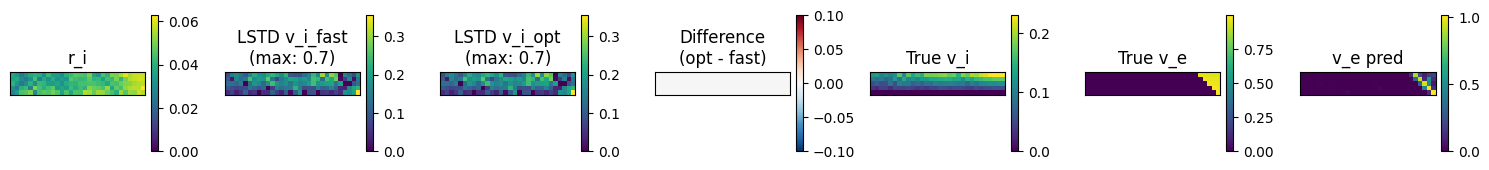

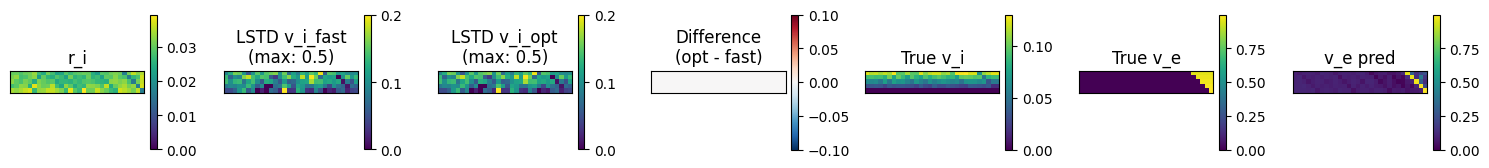

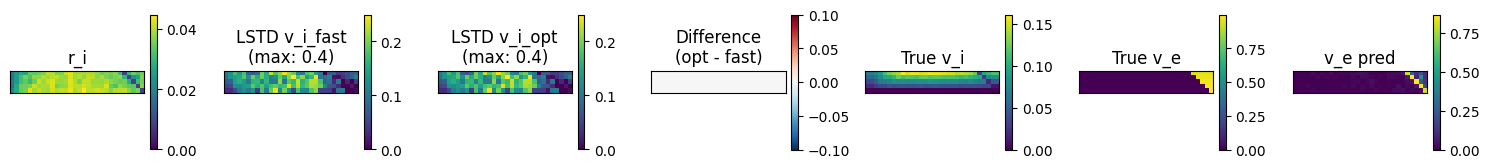

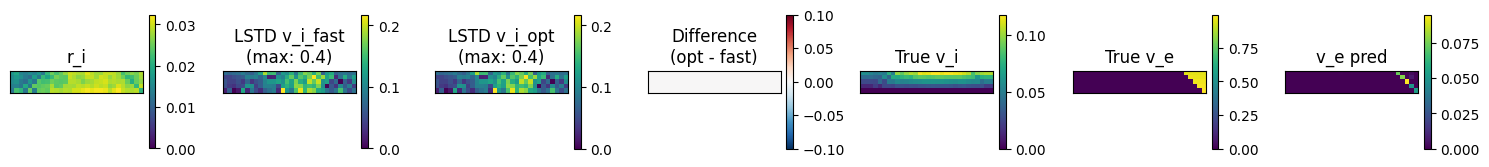

In [12]:
import matplotlib.pyplot as plt
import time

N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))
show_last_n_rows = 5
# Ts = [0,1,10,50, 200, 250, 300]
for T in Ts:
    fig, axes = plt.subplots(1, 7, figsize=(15, 4))
    # --- Plot 1: r_i ---
    im0 = axes[0].imshow(episodic_metrics['ri_grid'][SEED][T][-show_last_n_rows:], vmin=0)
    axes[0].set_title("r_i")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # --- Plot 2: v_i_fast (its own scale) ---
    im1 = axes[1].imshow(episodic_metrics['vi_pred'][SEED][T][-show_last_n_rows:], vmin=0)
    axes[1].set_title(f"LSTD v_i_fast\n(max: {jnp.max(episodic_metrics['vi_pred'][SEED][T]):.1f})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # --- Plot 3: v_i_opt (its own scale) ---
    im2 = axes[2].imshow(episodic_metrics['v_i_pred_opt'][SEED][T][-show_last_n_rows:], vmin=0)
    axes[2].set_title(f"LSTD v_i_opt\n(max: {jnp.max(episodic_metrics['v_i_pred_opt'][SEED][T]):.1f})")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # --- Plot 4: Difference (opt - fast) ---
    diff = (episodic_metrics['v_i_pred_opt'][SEED][T][-show_last_n_rows:] - episodic_metrics['vi_pred'][SEED][T][-show_last_n_rows:])
    im3 = axes[3].imshow(diff, cmap='RdBu_r', vmin=0, vmax=jnp.max(jnp.abs(diff)))
    axes[3].set_title("Difference\n(opt - fast)")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    # # # --- Plot 5: True v_i ---
    im4 = axes[4].imshow(episodic_metrics['v_i'][SEED][T][-show_last_n_rows:], vmin=0)
    axes[4].set_title("True v_i")
    plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

        # # # --- Plot 5: True v_i ---
    im5 = axes[5].imshow(episodic_metrics['v_e'][SEED][T][-show_last_n_rows:], vmin=0)
    axes[5].set_title("True v_e")
    plt.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

        # # # --- Plot 5: True v_i ---
    im6 = axes[6].imshow(episodic_metrics['v_e_pred'][SEED][T][-show_last_n_rows:], vmin=0)
    axes[6].set_title("v_e pred")
    plt.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    # plt.savefig(f'figures/grid_opt{T}.pdf')
    # # time.sleep(0.5)
    # # email_pdf(f'figures/grid_opt{T}.pdf')
    plt.show()

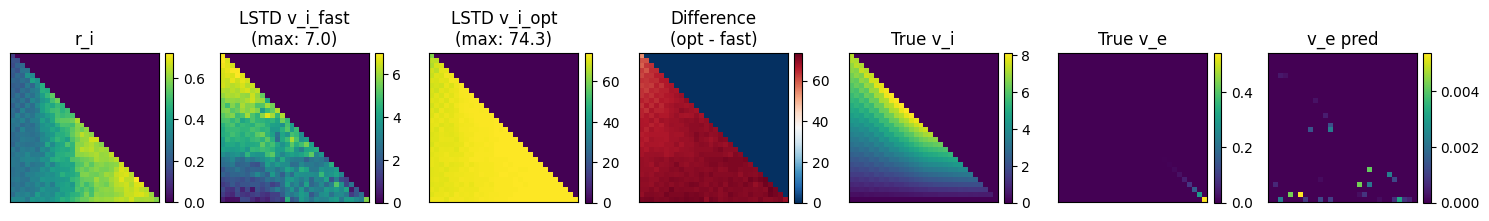

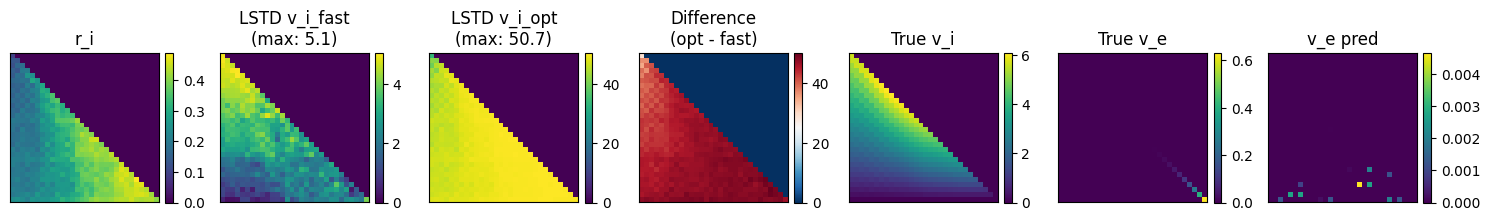

In [3]:
reachable_mask[None,:].shape

(1, 40, 40)

Text(0.5, 1.0, 'Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

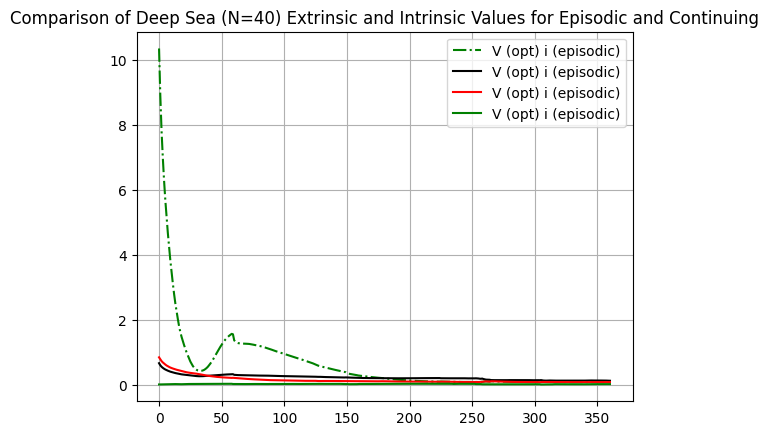

In [5]:
# plt.plot((net_metrics['v_e'].mean(0))[:,0,0], label = 'Network')
# plt.plot((episodic_metrics['v_e'].mean(0))[:,0,0], label = 'LSTD (optimistic)')
# # plt.plot((lstd_metrics_pess['v_e'].mean(0))[:,0,0], label = 'LSTD (pessimistic)')
# # plt.plot(lstd_metrics['fast_i_value_error'].mean(0), label = 'LSTD Fast i_val MSE')
# plt.legend()
# plt.title('Performance (Episodic)')
# plt.ylabel('Ve')
# plt.ylim(top=1, bottom=0)
# plt.savefig('figures/perf_opt_vs_pess_vs_net.pdf')
# email_pdf('figures/perf_opt_vs_pess_vs_net.pdf')
# # plt.yscale('log')

In [6]:
# plt.plot(net_metrics['i_value_error'].mean(0), label = 'network i_val MSE')
# plt.plot(episodic_metrics['fast_i_value_error'].mean(0), label = 'LSTD Fast i_val MSE')
# plt.legend()
# plt.title('Intrinsic Value Error')
# plt.ylabel('MSE (log scale)')
# plt.ylim(top=1, bottom=0)
# # plt.yscale('log')

In [7]:

import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

# 1. Setup & Masking
N = net_config['DEEPSEA_SIZE']
reachable_mask = np.tril(np.ones((N, N)))

def get_masked_grid(metric_array, step_idx, seed_idx=0):
    """Extracts grid, applies mask, and sets non-reachable to NaN for plotting."""
    grid = metric_array[seed_idx, step_idx]
    # Apply mask: Keep reachable, set others to NaN
    masked_grid = np.where(reachable_mask == 1, grid, np.nan)
    return masked_grid

# 2. Extract Data for Plotting
# Steps to visualize
t1, t2 = 10, 50

# Row 1: Network Data
net_true_t1 = get_masked_grid(net_metrics['v_i'], t1)
net_pred_t1 = get_masked_grid(net_metrics['v_i_pred'], t1)
net_true_t2 = get_masked_grid(net_metrics['v_i'], t2)
net_pred_t2 = get_masked_grid(net_metrics['v_i_pred'], t2)

# Row 2: LSTD Data
lstd_true_t1 = get_masked_grid(episodic_metrics['v_i'], t1)
lstd_pred_t1 = get_masked_grid(episodic_metrics['fast_v_i_pred'], t1) # Using fast_v_i_pred
lstd_true_t2 = get_masked_grid(episodic_metrics['v_i'], t2)
lstd_pred_t2 = get_masked_grid(episodic_metrics['fast_v_i_pred'], t2)

# 3. Compute Global Limits for Common Color Scale
all_grids = [
    net_true_t1, net_pred_t1, net_true_t2, net_pred_t2,
    lstd_true_t1, lstd_pred_t1, lstd_true_t2, lstd_pred_t2
]
# Use nanmin/nanmax to ignore the masked regions
vmin = np.nanmin(all_grids)
vmax = np.nanmax(all_grids)

# 4. Plotting
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Neural Network
rows = ["Neural Network", "LSTD"]
data_matrix = [
    [net_true_t1, net_pred_t1, net_true_t2, net_pred_t2],
    [lstd_true_t1, lstd_pred_t1, lstd_true_t2, lstd_pred_t2]
]

titles = [
    f"True V_i (Step {t1})", f"Pred V_i (Step {t1})", 
    f"True V_i (Step {t2})", f"Pred V_i (Step {t2})"
]

for row_idx in range(2):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        grid = data_matrix[row_idx][col_idx]
        
        im = ax.imshow(grid, cmap='viridis', vmin=vmin, vmax=vmax)
        
        # Formatting
        if col_idx == 0:
            ax.set_ylabel(rows[row_idx], fontsize=14, fontweight='bold')
        
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=12)
            
        ax.set_xticks([])
        ax.set_yticks([])

# Add a single Colorbar for the whole figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Intrinsic Value')

plt.suptitle(f"Intrinsic Value: Ground Truth vs Prediction (Steps {t1} & {t2})", fontsize=16)
plt.show()

NameError: name 'net_config' is not defined

KeyError: 'fast_v_i_pred'

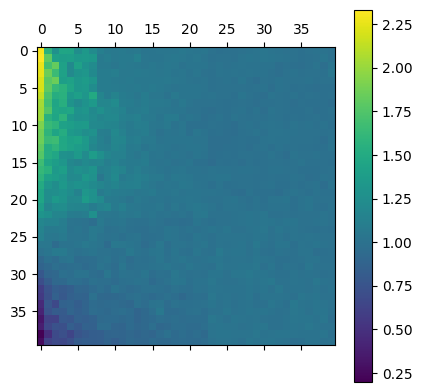

In [8]:
T = 10

plt.matshow(episodic_metrics['v_i_pred_opt'][0][T])
plt.colorbar()

plt.matshow(episodic_metrics['fast_v_i_pred'][0][T])
plt.colorbar()

In [11]:
T = 300
for t in range(T):
    differs = jnp.sum( episodic_metrics['fast_v_i_pred'][0][t] != episodic_metrics['v_i_pred_opt'][0][t])
    if differs > 0:
        print(f'differ at timestep {t}, by {differs}')

differ at timestep 0, by 1152
differ at timestep 1, by 1053
differ at timestep 2, by 791
differ at timestep 3, by 622
differ at timestep 4, by 452
differ at timestep 5, by 340
differ at timestep 6, by 281
differ at timestep 7, by 194
differ at timestep 8, by 117
differ at timestep 9, by 49
differ at timestep 10, by 9
differ at timestep 11, by 1


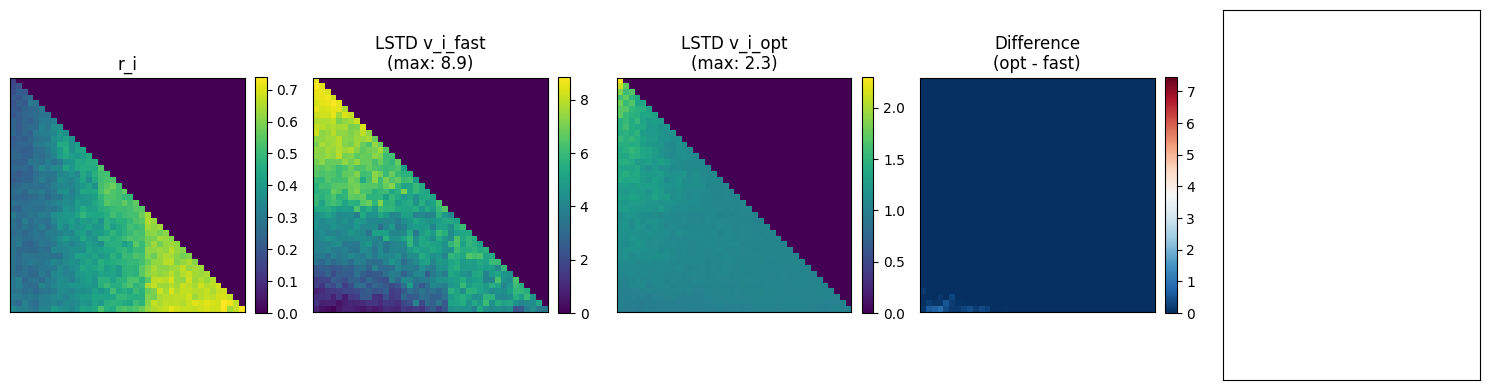

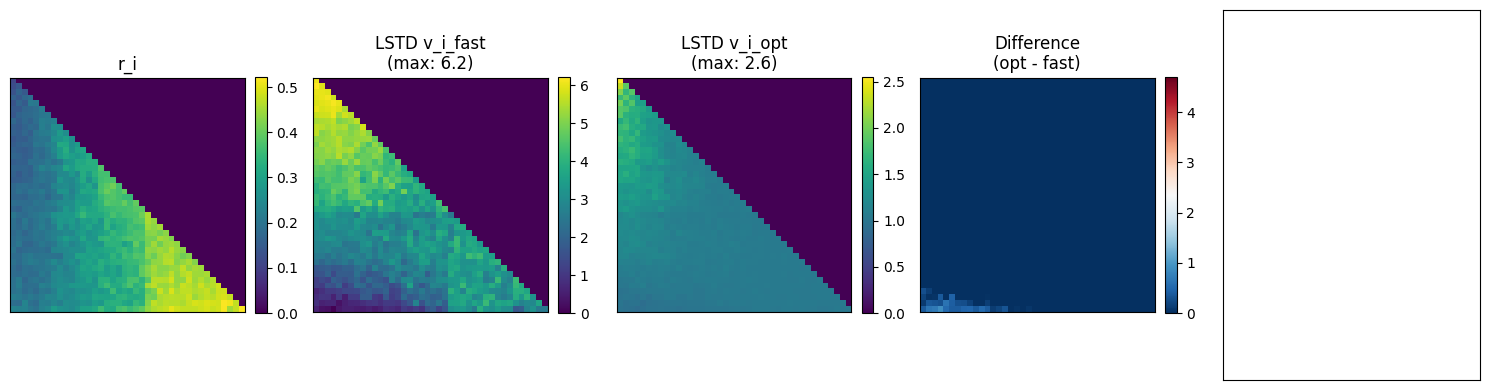

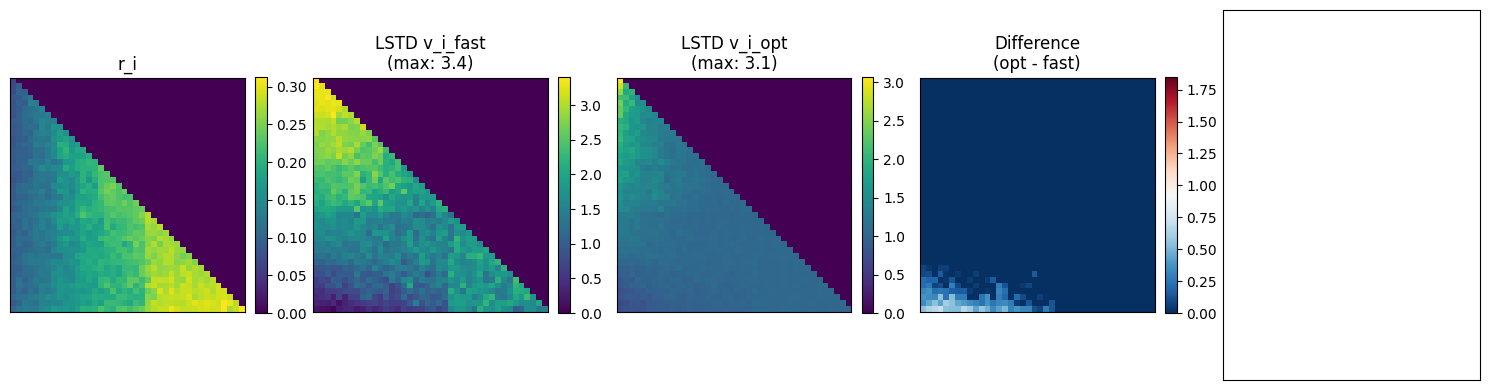

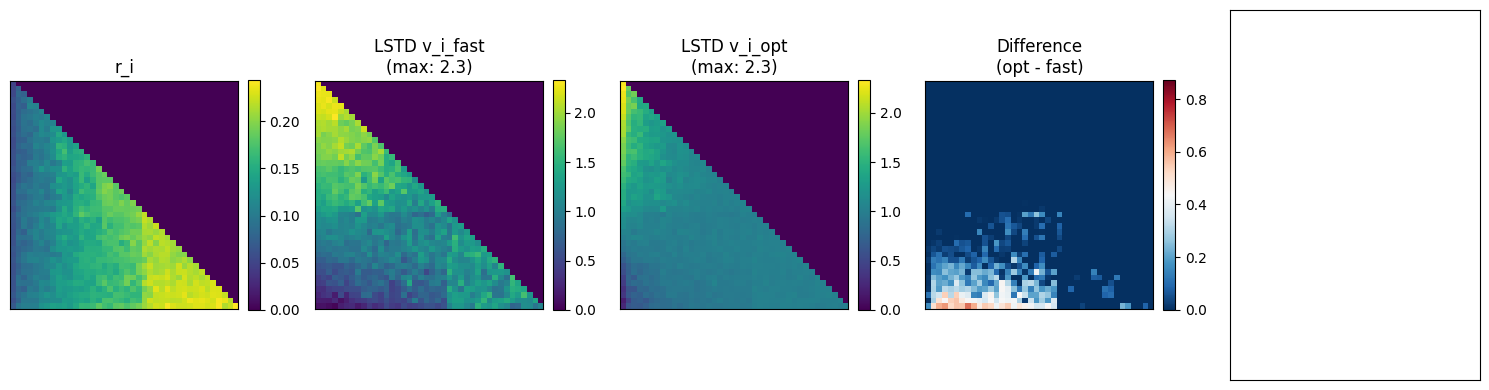

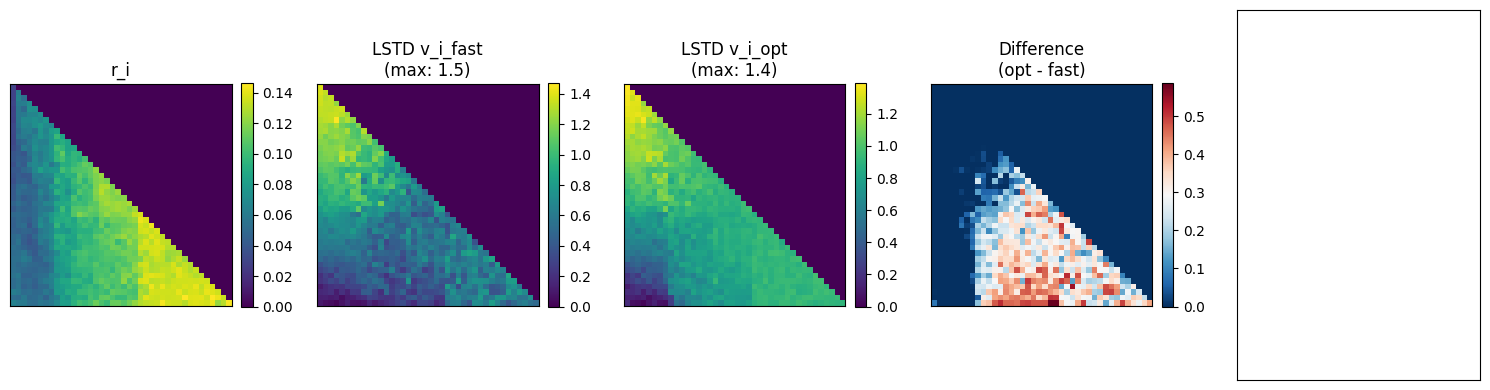

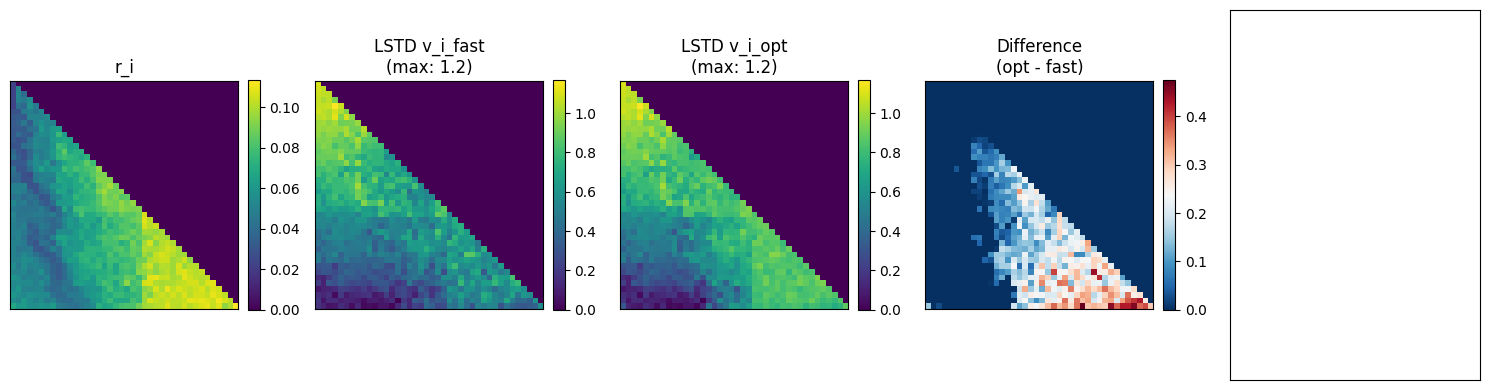

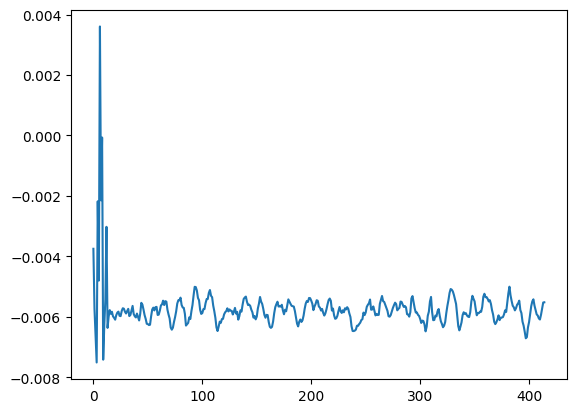

In [16]:
plt.plot(episodic_metrics['returned_episode_returns'].mean(0))

In [17]:
email_pdf('figures/grid_opt_vs_pess_vs_net.pdf')

📁 Found figures/grid_opt_vs_pess_vs_net.pdf (1.2 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

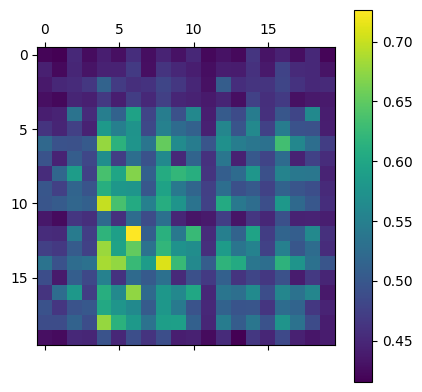

In [18]:
plt.matshow(net_metrics['v_i_pred'][0][T])
plt.colorbar(
    
)

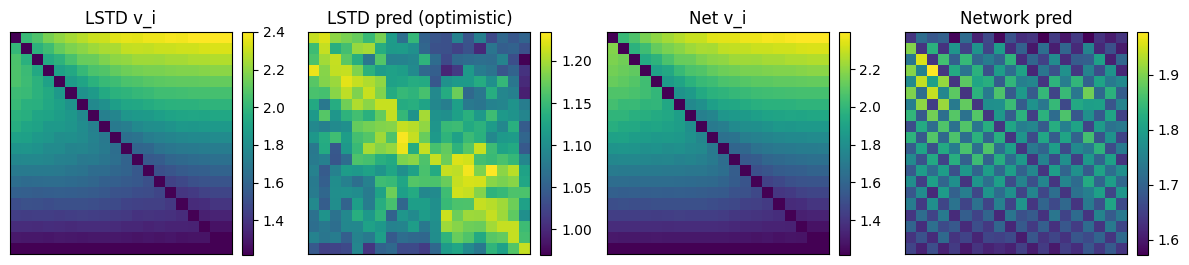

<Figure size 640x480 with 0 Axes>

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

T = 300

# --- Plot 1 ---
im0 = axes[0].imshow(lstd_metrics['v_i'][1][T])
axes[0].set_title("LSTD v_i")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Plot 2 ---
im1 = axes[1].imshow(lstd_metrics['fast_v_i_pred'][1][T])
axes[1].set_title("LSTD pred (optimistic)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(net_metrics['v_i'][1][T])
axes[2].set_title("Net v_i")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# --- Plot 3 ---
im3 = axes[3].imshow(net_metrics['v_i_pred'][1][T])
axes[3].set_title("Network pred")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# Optional cleanup
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

plt.savefig('figures/grid_opt_vs_pess_vs_net.pdf')

In [119]:
lstd_metrics['returned_episode_returns'][1][0:50]

Array([-4.2938236e-03, -4.9835211e-03, -5.8642584e-03, -6.3874517e-03,
       -6.2651373e-03, -6.5485844e-03, -6.7708744e-03, -2.0351568e-03,
        8.0102403e-04, -5.4577785e-04,  7.3183579e-03,  1.2005126e-02,
        2.7559325e-02,  8.9637816e-02,  1.9627233e-01,  3.0769604e-01,
        3.2686883e-01,  4.4688940e-01,  6.3088644e-01,  8.0875665e-01,
        9.6194494e-01,  9.8511958e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8877990e-01,
        9.8633969e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8511958e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01], dtype=float32)

In [120]:
lstd_metrics['ri_grid'][1][10][21]

Array([0.10640599, 0.10515695, 0.11935134, 0.1078482 , 0.09913049,
       0.08106329, 0.10425426, 0.09034334, 0.11678824, 0.09395612,
       0.12966631, 0.11989375, 0.13698503, 0.13067634, 0.14990346,
       0.15450154, 0.16357163, 0.15533471, 0.18128127, 0.1850642 ],      dtype=float32)

In [121]:
lstd_metrics['fast_v_i_pred'][1][10][20]

Array([6.5930495, 6.632838 , 6.5175924, 6.57241  , 6.822557 , 6.670576 ,
       6.809317 , 6.6961117, 6.658608 , 6.7689104, 6.6327014, 6.588842 ,
       6.648999 , 6.744011 , 6.5671678, 6.4181237, 6.5818157, 6.6403046,
       6.539092 , 6.3400154], dtype=float32)

In [122]:
lstd_metrics['v_i'][1][10][18]

Array([8.31544 , 8.32699 , 8.317549, 8.310685, 8.294276, 8.312863,
       8.295176, 8.319728, 8.303725, 8.335888, 8.315318, 8.345526,
       8.338468, 8.357414, 8.354732, 8.371591, 8.365342, 8.389491,
       8.392127, 8.394734], dtype=float32)